# Deep Agents Filesystem Experiment

This notebook compares **local mount** vs **gcsfuse mount** using the API wrapper.

## Objectives
1. Validate multi-tenant structure and concurrent behavior.
2. Evaluate canonical method applicability (`ls/als`, `read/aread`, `glob/aglob`, `grep/agrep`, `write/awrite`, `edit/aedit`, `upload_files/aupload_files`, `download_files/adownload_files`).
3. Run balanced benchmark scenarios and persist metrics as CSV.

In [48]:
from __future__ import annotations

from concurrent.futures import ThreadPoolExecutor
from datetime import datetime
import io
import json
import os
from pathlib import Path
import statistics
import time
import zipfile

import matplotlib.pyplot as plt
import pandas as pd
import requests

LOCAL_API = os.getenv('LOCAL_API_URL', 'http://localhost:8080')
GCS_API = os.getenv('GCS_API_URL', 'http://localhost:8081')
BACKENDS = {'local': LOCAL_API, 'gcsfuse': GCS_API}
TENANTS = ['tenant-a', 'tenant-b', 'tenant-c']
ITERATIONS = int(os.getenv('BENCH_ITERATIONS', '25'))
CONCURRENCY_LEVELS = [1, 5, 10, 20]

RUN_TS = datetime.now().strftime('%Y%m%d_%H%M%S')
RUN_DIR = Path('artifacts/results') / RUN_TS
RUN_DIR.mkdir(parents=True, exist_ok=True)

In [49]:
def _headers(tenant_id: str) -> dict[str, str]:
    """Build tenant-scoped request headers."""
    return {'X-Tenant-ID': tenant_id}


def health_check(base_url: str) -> dict:
    """Call service health endpoint."""
    response = requests.get(f'{base_url}/health', timeout=30)
    response.raise_for_status()
    return response.json()


def backend_info(base_url: str) -> dict:
    """Call backend metadata endpoint."""
    response = requests.get(f'{base_url}/v1/backend_info', timeout=30)
    response.raise_for_status()
    return response.json()


def call_json(base_url: str, method: str, tenant_id: str, payload: dict) -> dict:
    """Call one JSON API method and capture latency and payload details."""
    start = time.perf_counter()
    response = requests.post(
        f'{base_url}/v1/fs/{method}',
        headers=_headers(tenant_id),
        json=payload,
        timeout=120,
    )
    duration_ms = (time.perf_counter() - start) * 1000
    data = None
    text = None
    try:
        data = response.json()
    except Exception:
        text = response.text[:500]

    return {
        'status_code': response.status_code,
        'duration_ms': round(duration_ms, 3),
        'json': data,
        'text': text,
    }


def call_upload(base_url: str, method: str, tenant_id: str, path_to_content: dict[str, bytes]) -> dict:
    """Call upload endpoint (`upload_files` or `aupload_files`)."""
    files = []
    data = []
    for path, content in path_to_content.items():
        data.append(('paths', path))
        filename = Path(path).name or 'upload.bin'
        files.append(('files', (filename, content, 'application/octet-stream')))

    start = time.perf_counter()
    response = requests.post(
        f'{base_url}/v1/fs/{method}',
        headers=_headers(tenant_id),
        data=data,
        files=files,
        timeout=120,
    )
    duration_ms = (time.perf_counter() - start) * 1000
    return {
        'status_code': response.status_code,
        'duration_ms': round(duration_ms, 3),
        'json': response.json(),
    }


def call_download(base_url: str, method: str, tenant_id: str, paths: list[str]) -> dict:
    """Call download endpoint and unpack metadata from zip."""
    start = time.perf_counter()
    response = requests.post(
        f'{base_url}/v1/fs/{method}',
        headers=_headers(tenant_id),
        json={'paths': paths},
        timeout=120,
    )
    duration_ms = (time.perf_counter() - start) * 1000

    metadata = {}
    file_names = []
    if response.status_code == 200 and response.headers.get('content-type', '').startswith('application/zip'):
        with zipfile.ZipFile(io.BytesIO(response.content), 'r') as archive:
            file_names = sorted(archive.namelist())
            if '_metadata.json' in file_names:
                metadata = json.loads(archive.read('_metadata.json').decode('utf-8'))

    return {
        'status_code': response.status_code,
        'duration_ms': round(duration_ms, 3),
        'metadata': metadata,
        'file_names': file_names,
    }


def classify_result(status_code: int, payload: dict | None) -> str:
    """Classify endpoint result into PASS/DEGRADED/FAIL for the matrix."""
    if status_code != 200:
        return 'FAIL'
    if payload is None:
        return 'FAIL'

    top_error = payload.get('error')
    if top_error:
        return 'FAIL'

    result = payload.get('result')
    if isinstance(result, dict) and result.get('error'):
        return 'DEGRADED'
    return 'PASS'

## Part 1 - Multi-User / Tenancy / Concurrency

This section validates tenant path isolation (`/tenants/{tenant_id}/...`) and basic concurrent request behavior.

In [50]:
health_rows = []
for backend_name, base_url in BACKENDS.items():
    health = health_check(base_url)
    info = backend_info(base_url)
    health_rows.append({
        'backend': backend_name,
        'url': base_url,
        'status': health.get('status'),
        'mount_dir': health.get('mount_dir'),
        'virtual_mode': info.get('virtual_mode'),
        'tenant_prefix': info.get('tenant_root_prefix'),
    })

health_df = pd.DataFrame(health_rows)
health_df

,backend,url,status,mount_dir,virtual_mode,tenant_prefix
0,local,http://localhost:8080,ok,/mnt/local,True,/tenants/{tenant_id}
1,gcsfuse,http://localhost:8081,ok,/mnt/gcsfuse,True,/tenants/{tenant_id}


In [51]:
tenancy_checks = []

for backend_name, base_url in BACKENDS.items():
    for tenant_id in TENANTS:
        write_result = call_json(
            base_url,
            'write',
            tenant_id,
            {
                'file_path': f'/tenant-check/{tenant_id}.txt',
                'content': f'hello from {tenant_id}',
            },
        )
        tenancy_checks.append({
            'backend': backend_name,
            'tenant': tenant_id,
            'step': 'write',
            'status_code': write_result['status_code'],
            'classification': classify_result(write_result['status_code'], write_result.get('json')),
            'duration_ms': write_result['duration_ms'],
        })

    for source_tenant in TENANTS:
        for other_tenant in TENANTS:
            if source_tenant == other_tenant:
                continue
            read_result = call_json(
                base_url,
                'read',
                other_tenant,
                {'file_path': f'/tenant-check/{source_tenant}.txt'},
            )
            error_text = None
            payload = read_result.get('json') or {}
            if isinstance(payload.get('result'), dict):
                error_text = payload['result'].get('error')
            tenancy_checks.append({
                'backend': backend_name,
                'tenant': other_tenant,
                'step': f'cross-read-{source_tenant}',
                'status_code': read_result['status_code'],
                'classification': 'PASS' if error_text and 'not found' in error_text.lower() else 'DEGRADED',
                'duration_ms': read_result['duration_ms'],
            })

tenancy_df = pd.DataFrame(tenancy_checks)
tenancy_df.head(20)

,backend,tenant,step,status_code,classification,duration_ms
0,local,tenant-a,write,200,DEGRADED,4.620
1,local,tenant-b,write,200,DEGRADED,3.802
2,local,tenant-c,write,200,DEGRADED,2.678
3,local,tenant-b,cross-read-tenant-a,200,DEGRADED,3.754
4,local,tenant-c,cross-read-tenant-a,200,DEGRADED,3.166
5,local,tenant-a,cross-read-tenant-b,200,DEGRADED,4.331
6,local,tenant-c,cross-read-tenant-b,200,DEGRADED,3.242
7,local,tenant-a,cross-read-tenant-c,200,DEGRADED,4.284
8,local,tenant-b,cross-read-tenant-c,200,DEGRADED,2.662
9,gcsfuse,tenant-a,write,200,DEGRADED,612.862


In [52]:
def _concurrent_write_task(base_url: str, tenant_id: str, i: int) -> dict:
    return call_json(
        base_url,
        'write',
        tenant_id,
        {'file_path': f'/concurrency/item-{i}.txt', 'content': f'payload-{i}'},
    )


concurrency_rows = []
for backend_name, base_url in BACKENDS.items():
    for level in [5, 10, 20]:
        start = time.perf_counter()
        with ThreadPoolExecutor(max_workers=level) as pool:
            futures = [pool.submit(_concurrent_write_task, base_url, TENANTS[i % len(TENANTS)], i) for i in range(level)]
            results = [future.result() for future in futures]
        elapsed = (time.perf_counter() - start) * 1000

        success = sum(1 for item in results if item['status_code'] == 200)
        concurrency_rows.append({
            'backend': backend_name,
            'concurrency': level,
            'success_count': success,
            'total': len(results),
            'elapsed_ms': round(elapsed, 3),
        })

concurrency_df = pd.DataFrame(concurrency_rows)
concurrency_df

,backend,concurrency,success_count,total,elapsed_ms
0,local,5,5,5,13.368
1,local,10,10,10,23.861
2,local,20,20,20,39.182
3,gcsfuse,5,5,5,759.578
4,gcsfuse,10,10,10,643.736
5,gcsfuse,20,20,20,2049.034


## Part 2 - Canonical Method Applicability Matrix

The matrix marks each method run as:
- `PASS`: endpoint succeeded without top-level or method result error.
- `DEGRADED`: call returned but method-level error exists (for example missing file or unsupported behavior in scenario).
- `FAIL`: endpoint-level failure.

In [53]:
def _extract_method_error(payload_json: dict | None) -> str | None:
    """Extract top-level or method-level error text from a response payload.

    Args:
        payload_json: Parsed JSON response payload or ``None``.

    Returns:
        Error text when available, else ``None``.
    """
    if not isinstance(payload_json, dict):
        return None

    result = payload_json.get('result')
    if isinstance(result, dict) and result.get('error'):
        return str(result['error'])

    if payload_json.get('error'):
        return str(payload_json['error'])
    return None


def _build_retry_path(file_path: str) -> str:
    """Create a unique fallback file path for write collision handling.

    Args:
        file_path: Original target path.

    Returns:
        Fallback path with timestamp suffix.
    """
    suffix = datetime.now().strftime('%H%M%S_%f')
    dot_index = file_path.rfind('.')
    slash_index = file_path.rfind('/')
    if dot_index > slash_index:
        return f"{file_path[:dot_index]}-{suffix}{file_path[dot_index:]}"
    return f"{file_path}-{suffix}"


def _write_with_retry(
    base_url: str,
    method: str,
    tenant_id: str,
    file_path: str,
    content: str,
) -> tuple[dict, str, str | None]:
    """Run ``write``/``awrite`` and retry once if file already exists.

    Args:
        base_url: Backend service URL.
        method: One of ``write`` or ``awrite``.
        tenant_id: Tenant identifier.
        file_path: Requested write path.
        content: File content to write.

    Returns:
        Tuple of ``(result, effective_path, retry_note)``.
    """
    first_payload = {'file_path': file_path, 'content': content}
    first_result = call_json(base_url, method, tenant_id, first_payload)
    first_error = _extract_method_error(first_result.get('json') or {})
    if not first_error or 'already exists' not in first_error.lower():
        return first_result, file_path, None

    retry_path = _build_retry_path(file_path)
    retry_payload = {'file_path': retry_path, 'content': content}
    retry_result = call_json(base_url, method, tenant_id, retry_payload)
    return retry_result, retry_path, f'retry_path={retry_path}'


def _append_matrix_row(
    rows: list[dict],
    backend_name: str,
    method: str,
    result: dict,
    note_extra: str | None = None,
) -> None:
    """Append one row to method matrix rows.

    Args:
        rows: Matrix row accumulator.
        backend_name: Backend identifier label.
        method: Method name being recorded.
        result: Request helper result dictionary.
        note_extra: Optional additional note text.

    Returns:
        None.
    """
    payload_json = result.get('json') or {}
    base_note = _extract_method_error(payload_json)
    note = base_note
    if note_extra:
        note = f'{base_note}; {note_extra}' if base_note else note_extra

    rows.append({
        'backend': backend_name,
        'method': method,
        'status_code': result['status_code'],
        'classification': classify_result(result['status_code'], payload_json),
        'duration_ms': result['duration_ms'],
        'note': note,
    })


matrix_run_tag = datetime.now().strftime('%Y%m%d_%H%M%S_%f')
matrix_rows = []

for backend_name, base_url in BACKENDS.items():
    tenant_id = TENANTS[0]

    # Clean execution namespace by using a unique matrix root for each run.
    matrix_root = f'/matrix/{matrix_run_tag}-{backend_name}'
    write_target = f'{matrix_root}/test-write-{matrix_run_tag}.txt'
    awrite_target = f'{matrix_root}/test-awrite-{matrix_run_tag}.txt'

    upload_sync = call_upload(
        base_url,
        'upload_files',
        tenant_id,
        {f'{matrix_root}/upload-sync.txt': b'upload sync data'},
    )
    matrix_rows.append({
        'backend': backend_name,
        'method': 'upload_files',
        'status_code': upload_sync['status_code'],
        'classification': classify_result(upload_sync['status_code'], upload_sync.get('json')),
        'duration_ms': upload_sync['duration_ms'],
        'note': _extract_method_error(upload_sync.get('json') or {}),
    })

    upload_async = call_upload(
        base_url,
        'aupload_files',
        tenant_id,
        {f'{matrix_root}/upload-async.txt': b'upload async data'},
    )
    matrix_rows.append({
        'backend': backend_name,
        'method': 'aupload_files',
        'status_code': upload_async['status_code'],
        'classification': classify_result(upload_async['status_code'], upload_async.get('json')),
        'duration_ms': upload_async['duration_ms'],
        'note': _extract_method_error(upload_async.get('json') or {}),
    })

    write_result, write_path, write_retry_note = _write_with_retry(
        base_url=base_url,
        method='write',
        tenant_id=tenant_id,
        file_path=write_target,
        content='matrix data',
    )
    _append_matrix_row(
        matrix_rows,
        backend_name,
        'write',
        write_result,
        note_extra=f'path={write_path}' if not write_retry_note else f'path={write_path}; {write_retry_note}',
    )

    awrite_result, awrite_path, awrite_retry_note = _write_with_retry(
        base_url=base_url,
        method='awrite',
        tenant_id=tenant_id,
        file_path=awrite_target,
        content='matrix async data',
    )
    _append_matrix_row(
        matrix_rows,
        backend_name,
        'awrite',
        awrite_result,
        note_extra=f'path={awrite_path}' if not awrite_retry_note else f'path={awrite_path}; {awrite_retry_note}',
    )

    method_cases = [
        ('ls', {'path': '/'}),
        ('als', {'path': '/'}),
        ('read', {'file_path': write_path}),
        ('aread', {'file_path': awrite_path}),
        ('edit', {'file_path': write_path, 'old_string': 'matrix', 'new_string': 'matrix-edited', 'replace_all': False}),
        ('aedit', {'file_path': awrite_path, 'old_string': 'matrix', 'new_string': 'matrix-updated', 'replace_all': False}),
        ('glob', {'pattern': '*.txt', 'path': matrix_root}),
        ('aglob', {'pattern': '*.txt', 'path': matrix_root}),
        ('grep', {'pattern': 'matrix', 'path': matrix_root, 'glob': '*.txt'}),
        ('agrep', {'pattern': 'matrix', 'path': matrix_root, 'glob': '*.txt'}),
    ]

    for method, payload in method_cases:
        result = call_json(base_url, method, tenant_id, payload)
        _append_matrix_row(matrix_rows, backend_name, method, result)

    download_sync = call_download(
        base_url,
        'download_files',
        tenant_id,
        [
            f'{matrix_root}/upload-sync.txt',
            f'{matrix_root}/upload-async.txt',
            f'{matrix_root}/missing.txt',
        ],
    )
    matrix_rows.append({
        'backend': backend_name,
        'method': 'download_files',
        'status_code': download_sync['status_code'],
        'classification': 'PASS' if download_sync['status_code'] == 200 else 'FAIL',
        'duration_ms': download_sync['duration_ms'],
        'note': f"files={len(download_sync.get('metadata', {}).get('files', []))}",
    })

    download_async = call_download(
        base_url,
        'adownload_files',
        tenant_id,
        [f'{matrix_root}/upload-sync.txt', f'{matrix_root}/upload-async.txt'],
    )
    matrix_rows.append({
        'backend': backend_name,
        'method': 'adownload_files',
        'status_code': download_async['status_code'],
        'classification': 'PASS' if download_async['status_code'] == 200 else 'FAIL',
        'duration_ms': download_async['duration_ms'],
        'note': f"files={len(download_async.get('metadata', {}).get('files', []))}",
    })

method_matrix_df = pd.DataFrame(matrix_rows)
method_matrix_df.sort_values(['backend', 'method'])


,backend,method,status_code,classification,duration_ms,note
31,gcsfuse,adownload_files,200,PASS,11.657,files=2
25,gcsfuse,aedit,200,PASS,504.917,NaN
27,gcsfuse,aglob,200,PASS,307.755,NaN
29,gcsfuse,agrep,200,PASS,204.515,NaN
21,gcsfuse,als,200,PASS,97.171,NaN
23,gcsfuse,aread,200,PASS,102.859,NaN
17,gcsfuse,aupload_files,200,PASS,505.842,NaN
19,gcsfuse,awrite,200,PASS,617.330,path=/matrix/20260403_032829_985661-gcsfuse/test-awrite-20260403_032829_985661.txt
30,gcsfuse,download_files,200,PASS,308.591,files=3
24,gcsfuse,edit,200,PASS,508.446,NaN


In [54]:
pivot = method_matrix_df.pivot(index='method', columns='backend', values='classification')
pivot

backend,gcsfuse,local
method,,
adownload_files,PASS,PASS
aedit,PASS,PASS
aglob,PASS,PASS
agrep,PASS,PASS
als,PASS,PASS
aread,PASS,PASS
aupload_files,PASS,PASS
awrite,PASS,PASS
download_files,PASS,PASS


## Part 3 - Balanced Benchmark Suite

Scenarios:
1. Read latency (`read`)
2. Write throughput under varying concurrency (`write`)
3. List-heavy operations (`ls`)

In [55]:
benchmark_rows = []

def run_read_latency(backend_name: str, base_url: str, tenant_id: str, iterations: int) -> None:
    seed = call_json(base_url, 'write', tenant_id, {'file_path': '/bench/read-target.txt', 'content': 'x\n' * 500})
    _ = seed
    for i in range(iterations):
        result = call_json(base_url, 'read', tenant_id, {'file_path': '/bench/read-target.txt'})
        benchmark_rows.append({
            'backend': backend_name,
            'scenario': 'read_latency',
            'iteration': i,
            'concurrency': 1,
            'duration_ms': result['duration_ms'],
            'status_code': result['status_code'],
        })


def run_write_throughput(backend_name: str, base_url: str, tenant_id: str, concurrency: int) -> None:
    def _task(i: int) -> dict:
        return call_json(
            base_url,
            'write',
            tenant_id,
            {'file_path': f'/bench/write/{concurrency}/item-{i}.txt', 'content': f'data-{i}'},
        )

    start = time.perf_counter()
    with ThreadPoolExecutor(max_workers=concurrency) as pool:
        results = list(pool.map(_task, range(concurrency)))
    elapsed_s = time.perf_counter() - start

    success_count = sum(1 for item in results if item['status_code'] == 200)
    benchmark_rows.append({
        'backend': backend_name,
        'scenario': 'write_throughput',
        'iteration': 0,
        'concurrency': concurrency,
        'duration_ms': round(elapsed_s * 1000, 3),
        'status_code': 200 if success_count == concurrency else 500,
        'throughput_ops_sec': round(success_count / elapsed_s, 3) if elapsed_s > 0 else 0.0,
    })


def run_list_heavy(backend_name: str, base_url: str, tenant_id: str, iterations: int) -> None:
    for i in range(20):
        _ = call_json(
            base_url,
            'write',
            tenant_id,
            {'file_path': f'/bench/list-heavy/item-{i}.txt', 'content': 'list'},
        )

    for i in range(iterations):
        result = call_json(base_url, 'ls', tenant_id, {'path': '/bench/list-heavy'})
        benchmark_rows.append({
            'backend': backend_name,
            'scenario': 'list_heavy_ls',
            'iteration': i,
            'concurrency': 1,
            'duration_ms': result['duration_ms'],
            'status_code': result['status_code'],
        })


for backend_name, base_url in BACKENDS.items():
    tenant_id = TENANTS[0]
    run_read_latency(backend_name, base_url, tenant_id, ITERATIONS)
    run_list_heavy(backend_name, base_url, tenant_id, ITERATIONS)
    for level in CONCURRENCY_LEVELS:
        run_write_throughput(backend_name, base_url, tenant_id, level)

benchmark_df = pd.DataFrame(benchmark_rows)
benchmark_df.head()

,backend,scenario,iteration,concurrency,duration_ms,status_code,throughput_ops_sec
0,local,read_latency,0,1,3.854,200,NaN
1,local,read_latency,1,1,3.824,200,NaN
2,local,read_latency,2,1,4.838,200,NaN
3,local,read_latency,3,1,4.408,200,NaN
4,local,read_latency,4,1,3.482,200,NaN


In [56]:
latency_df = benchmark_df[benchmark_df['scenario'].isin(['read_latency', 'list_heavy_ls'])].copy()
throughput_df = benchmark_df[benchmark_df['scenario'] == 'write_throughput'].copy()

summary_rows = []
for (backend, scenario), group in benchmark_df.groupby(['backend', 'scenario']):
    durations = group['duration_ms'].tolist()
    summary_rows.append({
        'backend': backend,
        'scenario': scenario,
        'samples': len(group),
        'status_ok_pct': round((group['status_code'] == 200).mean() * 100, 2),
        'latency_mean_ms': round(statistics.mean(durations), 3),
        'latency_p95_ms': round(float(pd.Series(durations).quantile(0.95)), 3),
        'latency_max_ms': round(max(durations), 3),
    })

summary_df = pd.DataFrame(summary_rows).sort_values(['scenario', 'backend'])
summary_df

,backend,scenario,samples,status_ok_pct,latency_mean_ms,latency_p95_ms,latency_max_ms
0,gcsfuse,list_heavy_ls,25,100.0,230.356,304.717,721.434
3,local,list_heavy_ls,25,100.0,6.870,8.889,13.168
1,gcsfuse,read_latency,25,100.0,6.801,9.393,9.853
4,local,read_latency,25,100.0,4.017,5.969,6.357
2,gcsfuse,write_throughput,4,100.0,877.927,1275.503,1338.836
5,local,write_throughput,4,100.0,37.019,91.369,101.784


In [57]:
summary_path = RUN_DIR / 'summary.csv'
latency_path = RUN_DIR / 'latency.csv'
throughput_path = RUN_DIR / 'throughput.csv'
errors_path = RUN_DIR / 'errors.csv'
matrix_path = RUN_DIR / 'method_matrix.csv'

summary_df.to_csv(summary_path, index=False)
latency_df.to_csv(latency_path, index=False)
throughput_df.to_csv(throughput_path, index=False)
method_matrix_df.to_csv(matrix_path, index=False)

error_df = method_matrix_df[method_matrix_df['classification'] != 'PASS'].copy()
error_df.to_csv(errors_path, index=False)

print('Saved:')
print(f'- {summary_path}')
print(f'- {latency_path}')
print(f'- {throughput_path}')
print(f'- {errors_path}')
print(f'- {matrix_path}')

Saved:
- artifacts/results/20260403_030213/summary.csv
- artifacts/results/20260403_030213/latency.csv
- artifacts/results/20260403_030213/throughput.csv
- artifacts/results/20260403_030213/errors.csv
- artifacts/results/20260403_030213/method_matrix.csv


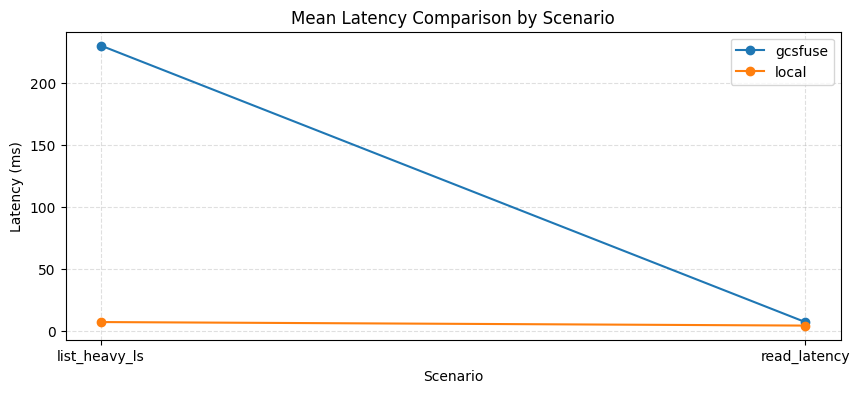

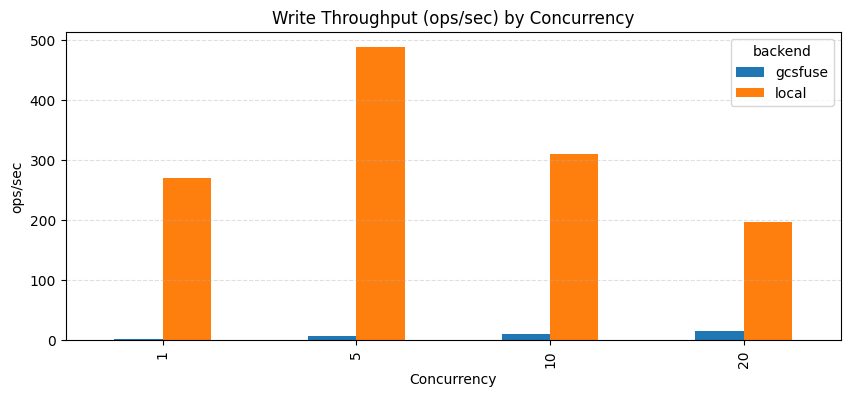

In [59]:
plt.figure(figsize=(10, 4))
plot_df = summary_df[summary_df['scenario'].isin(['read_latency', 'list_heavy_ls'])]
for backend in plot_df['backend'].unique():
    subset = plot_df[plot_df['backend'] == backend]
    plt.plot(subset['scenario'], subset['latency_mean_ms'], marker='o', label=backend)

plt.title('Mean Latency Comparison by Scenario')
plt.ylabel('Latency (ms)')
plt.xlabel('Scenario')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

throughput_plot = throughput_df[['backend', 'concurrency', 'throughput_ops_sec']].copy()
throughput_pivot = throughput_plot.pivot(index='concurrency', columns='backend', values='throughput_ops_sec')
throughput_pivot.plot(kind='bar', figsize=(10, 4), title='Write Throughput (ops/sec) by Concurrency')
plt.ylabel('ops/sec')
plt.xlabel('Concurrency')
plt.grid(True, axis='y', linestyle='--', alpha=0.4)
plt.show()